In [1]:
import sys
from pathlib import Path

sys.path.insert(0, '../../')
import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

plot_dir = Path('validation_fiber_assignment_data')
plot_dir.mkdir(exist_ok=True)
ext = 'pdf'

### Plot of angular upweights

- **Baseline:** `data-dr2-v2`
- **NN:** `data-dr2-test`

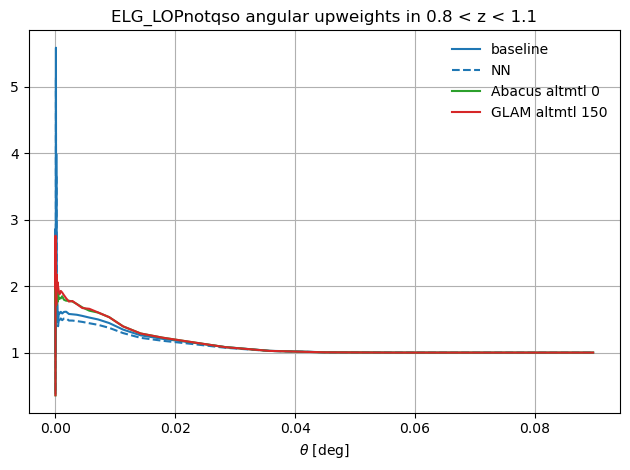

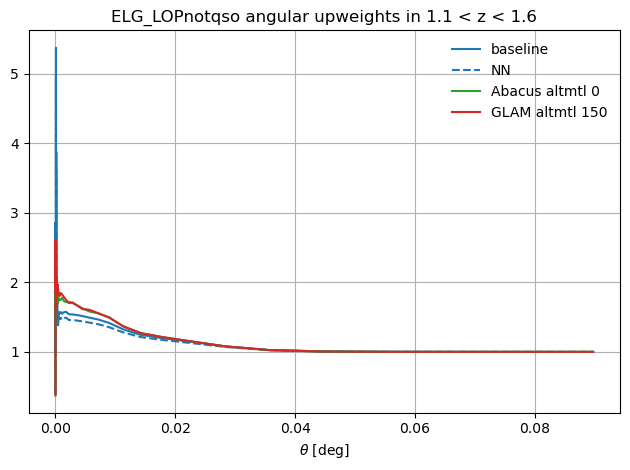

In [2]:
for tracer in ['ELG_LOPnotqso']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['particle2_angular_upweights', 'particle3_angular_upweights'][:1]:
            stats_dir = tools.base_stats_dir
            project = 'full_shape/fiber_assignment_systematics'
            region = 'NGC'
            fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='data-dr2-v2',
                                    zrange=zrange, tracer=tracer, region=region, weight='default-FKP')
            angular_data = types.read(fn)
            fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='data-dr2-test',
                                    zrange=zrange, tracer=tracer, region=region, weight='default-FKP')
            angular_data_nn = types.read(fn)
            fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='abacus-hf-dr2-v2-altmtl',
                                    zrange=zrange, tracer=tracer, region=region, weight='default-FKP', imock=0)
            angular_mock1 = types.read(fn)
            fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version='glam-uchuu-v2-altmtl',
                                    zrange=zrange, tracer=tracer, region=region, weight='default-FKP', imock=150)
            angular_mock2 = types.read(fn)
            if 'particle2' in kind:
                fig, ax = plt.subplots()
                angular = angular_data.get('DD')
                ax.plot(angular.coords('theta'), angular.value(), color='C0', linestyle='-', label='baseline')
                angular = angular_data_nn.get('DD')
                ax.plot(angular.coords('theta'), angular.value(), color='C0', linestyle='--', label='NN')
                angular = angular_mock1.get('DD')
                ax.plot(angular.coords('theta'), angular.value(), color='C2', linestyle='-', label='Abacus altmtl 0')
                angular = angular_mock2.get('DD')
                ax.plot(angular.coords('theta'), angular.value(), color='C3', linestyle='-', label='GLAM altmtl 150')
                ax.set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
                ax.grid(True)
                ax.legend(frameon=False)
                ax.set_title(f'{tracer} angular upweights in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            elif 'particle3' in kind:
                fig, ax = plt.subplots()
                angular = angular_data.get('DDD')
                theta = angular.coords('theta1')
                idx = (np.arange(len(theta)),) * 3
                ax.plot(theta, angular.value()[idx], color='C0', linestyle='-', label='data with original weights')
                angular = angular_data_nn.get('DDD')
                theta = angular.coords('theta1')
                idx = (np.arange(len(theta)),) * 3
                ax.plot(theta, angular.value()[idx], color='C0', linestyle='--', label='data with NN weights')
                angular = angular_mock1.get('DDD')
                theta = angular.coords('theta1')
                idx = (np.arange(len(theta)),) * 3
                ax.plot(theta, angular.value()[idx], color='C2', linestyle='-', label='Abacus altmtl 0')
                ax.set_xlabel(r'$\theta$ [$\mathrm{deg}$]')
                ax.grid(True)
                ax.legend(frameon=False)
                ax.set_xlim(0., 0.05)
                ax.set_title(f'{tracer} angular upweights in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            basename = f'{kind}_{tracer}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()
                

### Comparison of data and mocks

The bottom panels show the AUW correction, divided by the statistical uncertainty.
$P(k)$ AUW of data looks reasonable compared to the mocks, but much noiser for $B(k)$.

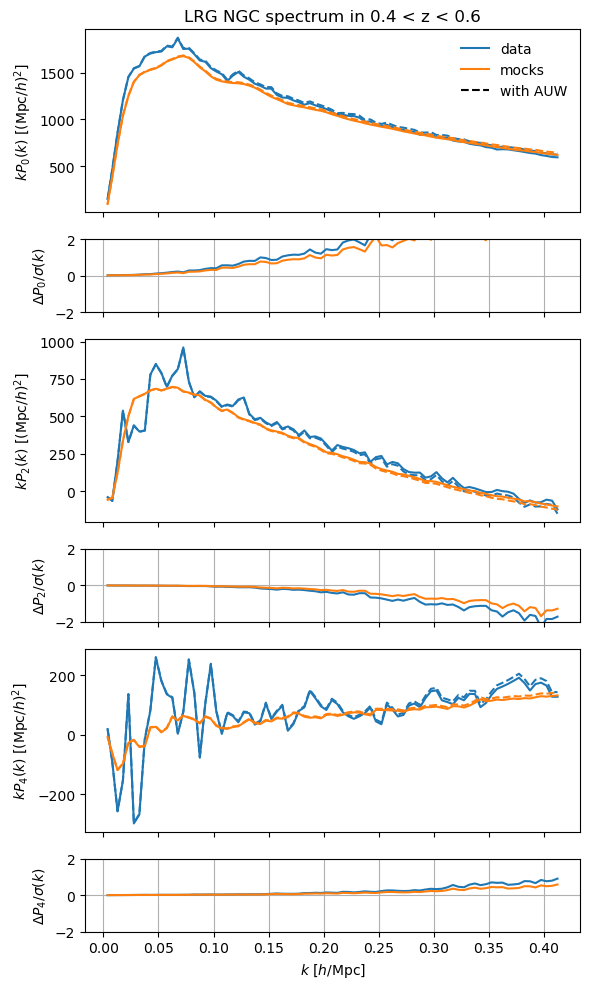

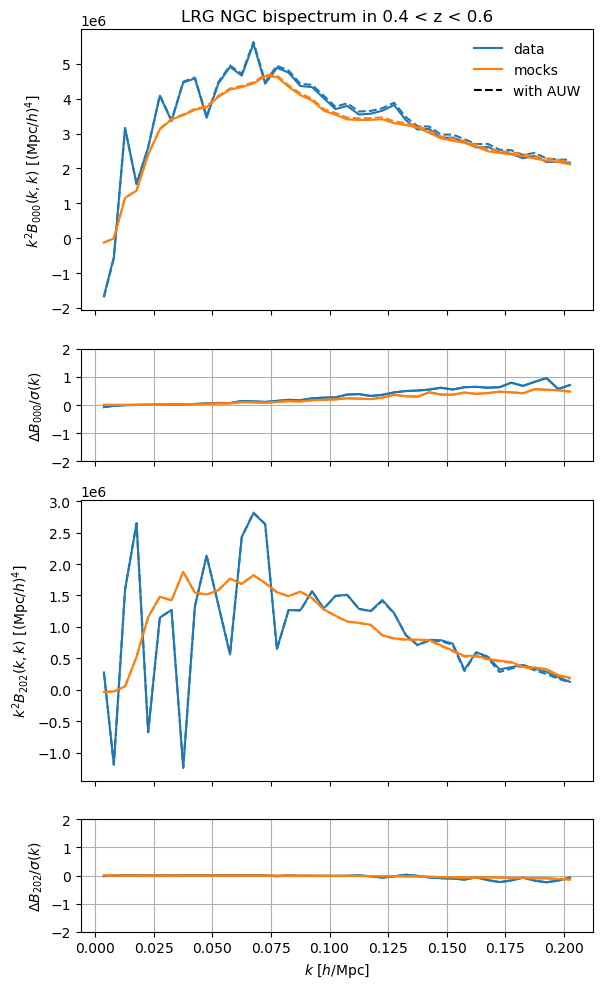

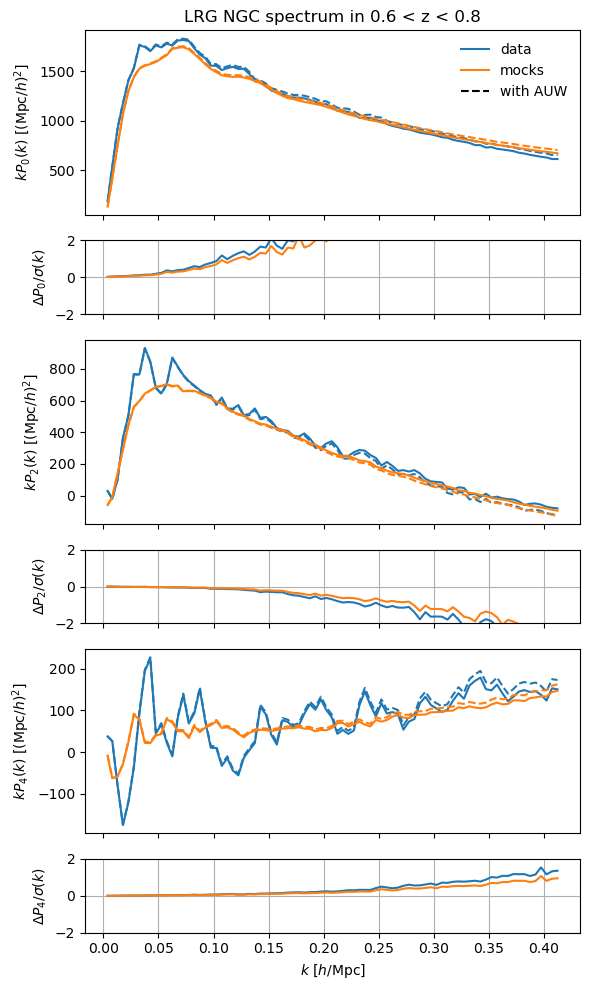

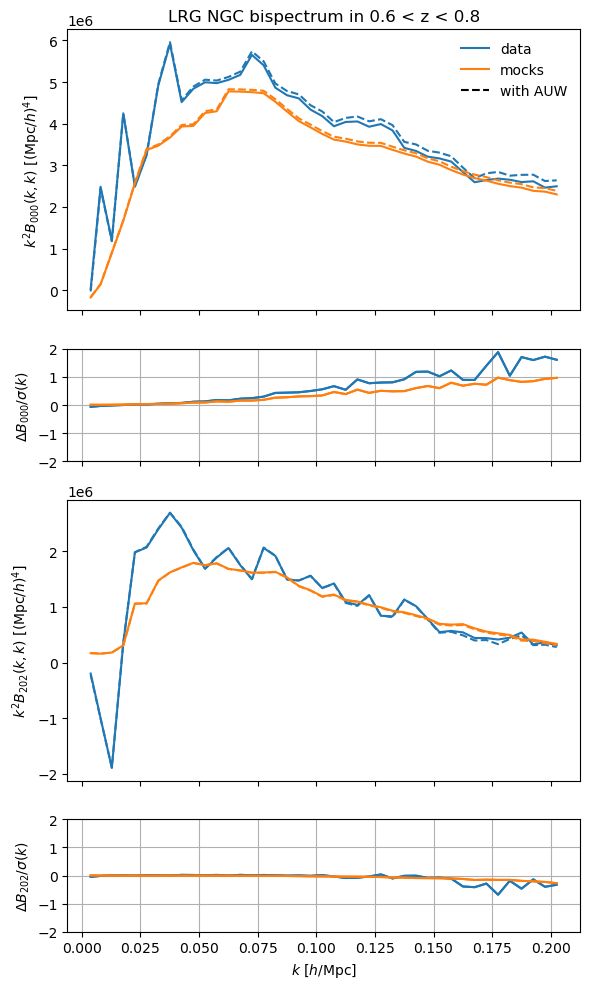

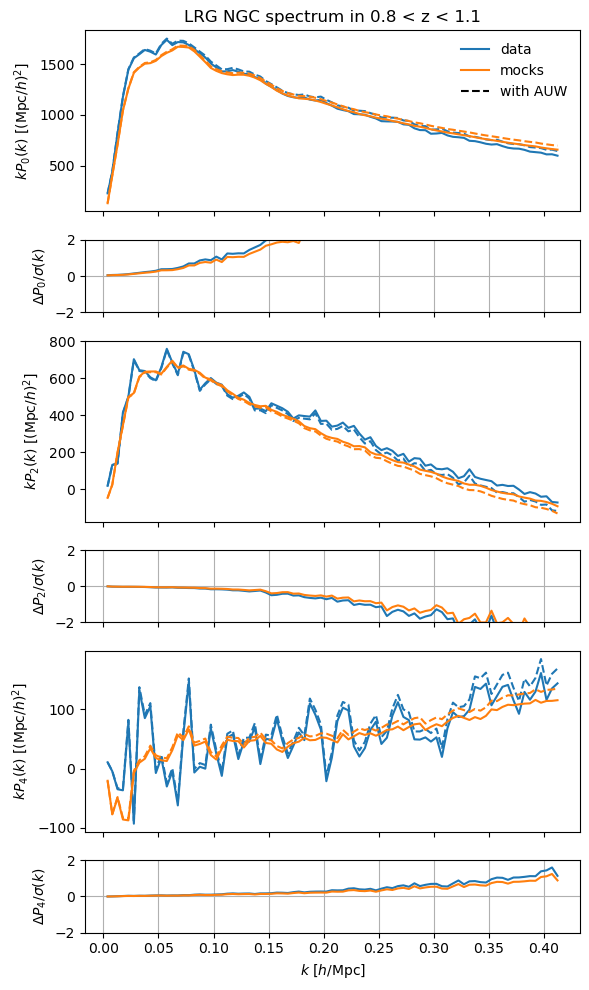

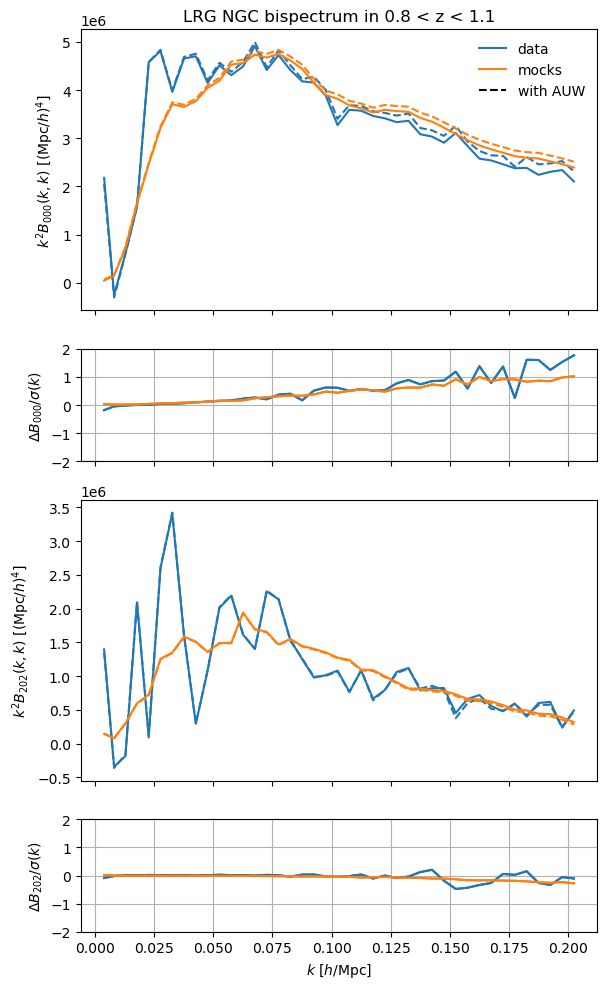

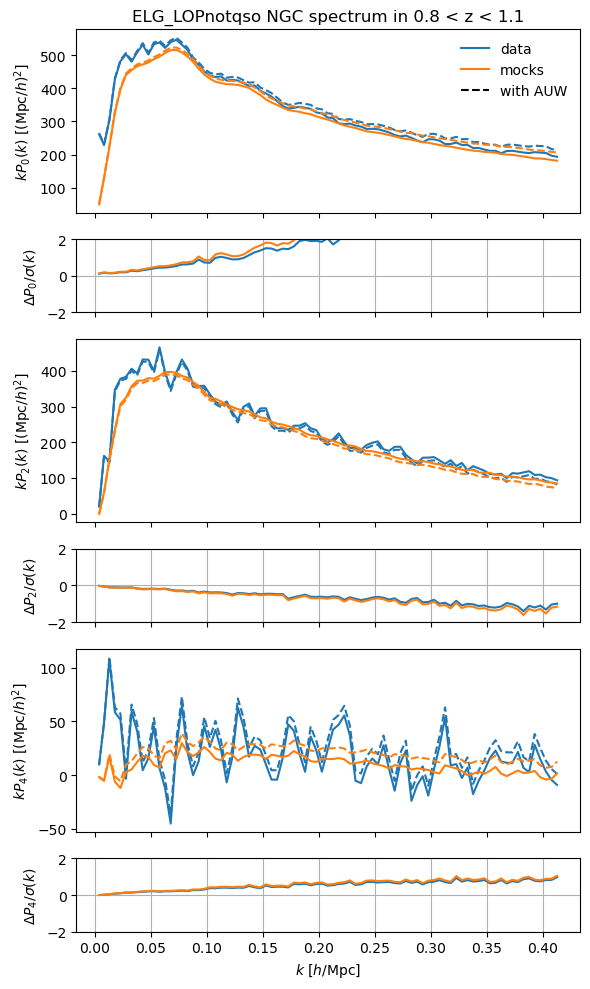

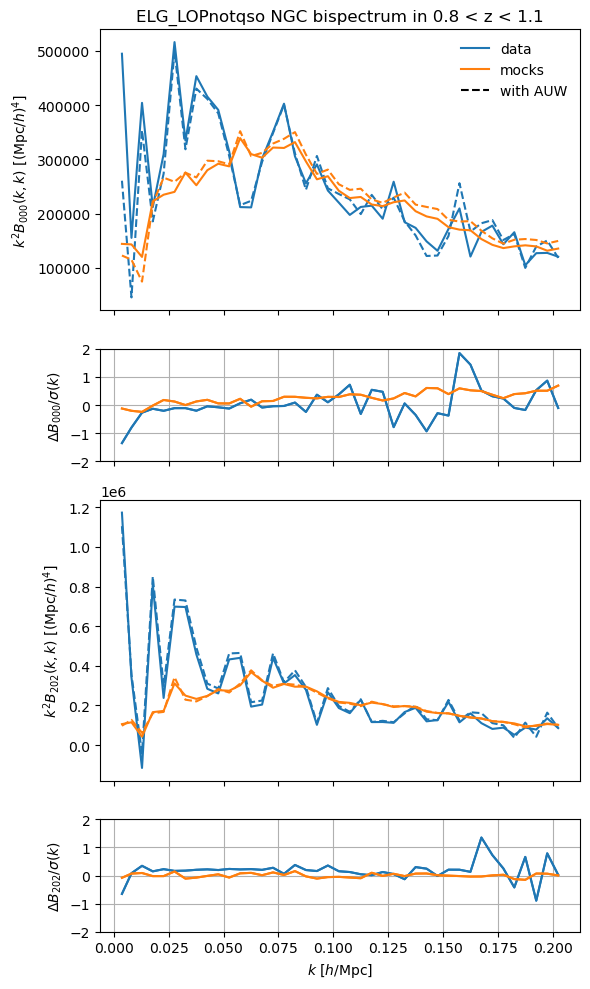

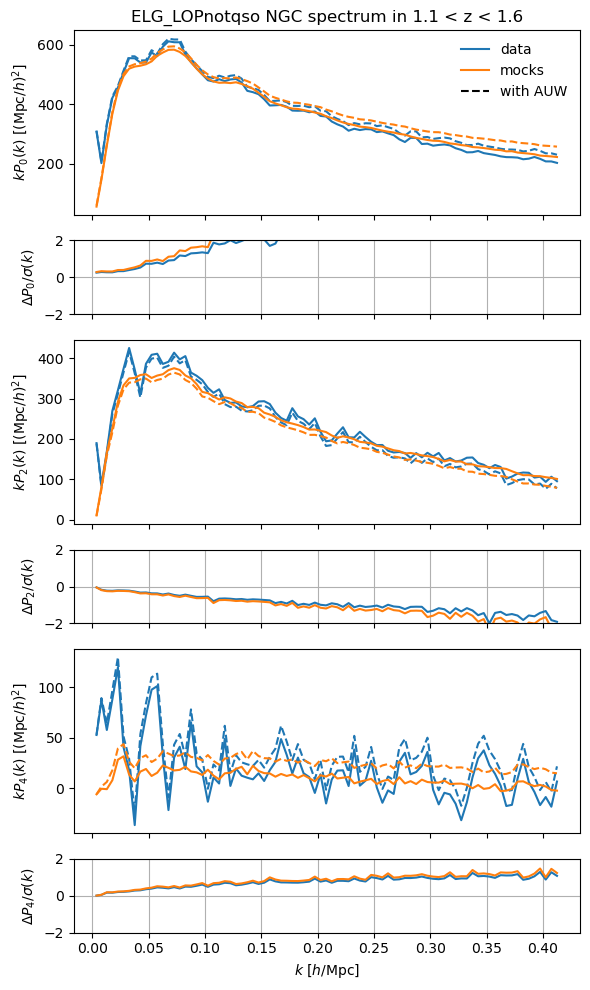

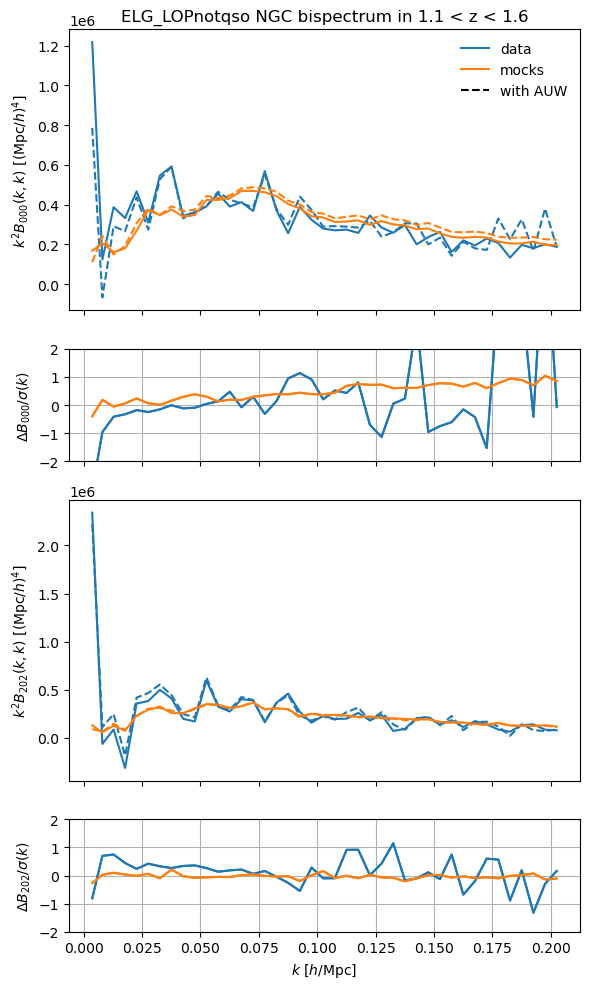

In [3]:
for tracer in ['LRG', 'ELG_LOPnotqso']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum', 'mesh3_spectrum']:
            stats_dir = tools.base_stats_dir
            region = 'NGC'
            version = 'holi-v3-altmtl'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]

            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
            mean = cov.observable

            version = 'data-dr2-v2'
            project = 'full_shape/fiber_assignment_systematics'
            fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal')
            data = types.read(fn).match(mean)
            fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', auw=True)
            data_auw = types.read(fn).match(mean)

            nmocks = 25
            version = 'abacus-hf-dr2-v2-altmtl'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal',
                                      imock=imock) for imock in range(nmocks)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean = types.mean(mocks).match(mean)
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal',
                                      imock=imock, auw=True) for imock in range(nmocks)]
            mocks = [types.read(fn) for fn in fns if fn.exists()]
            mean_auw = types.mean(mocks).match(mean)
            nmocks = len(mocks)  # scale error bars

            if 'mesh2' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(mean.ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    pole = data.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color='C0', linestyle='-')
                    pole = data_auw.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color='C0', linestyle='--')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color='C1', linestyle='-')
                    pole = mean_auw.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color='C1', linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-2., 2.)
                    std = cov.at.observable.get(ell).std() # / nmocks**0.5
                    pole = data.get(ell)
                    pole_auw = data_auw.get(ell)
                    ax.plot(pole.coords('k'), (pole_auw.value() - pole.value()) / std, color='C0', linestyle='-')
                    pole = mean.get(ell)
                    pole_auw = mean_auw.get(ell)
                    ax.plot(pole.coords('k'), (pole_auw.value() - pole.value()) / std, color='C1', linestyle='-')
                ax = lax[0]
                ax.plot([], [], color='C0', linestyle='-', label='data')
                ax.plot([], [], color='C1', linestyle='-', label='mocks')
                ax.plot([], [], color='k', linestyle='--', label='with AUW')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            elif 'mesh3' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
                    color = f'C{ill:d}'
                    pole = data.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C0', linestyle='-')
                    pole = data_auw.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C0', linestyle='--')
                    pole = mean.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C1', linestyle='-')
                    pole = mean_auw.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C1', linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-2., 2.)
                    #ax.set_ylim(-5e4, 5e4)
                    std = cov.at.observable.get(ell).std() # / nmocks**0.5
                    pole = data.get(ell)
                    pole_auw = data_auw.get(ell)
                    ax.plot(pole.coords('k'), (pole_auw.value() - pole.value()) / std, color='C0', linestyle='-')
                    pole = mean.get(ell)
                    pole_auw = mean_auw.get(ell)
                    ax.plot(pole.coords('k'), (pole_auw.value() - pole.value()) / std, color='C1', linestyle='-')
                    
                ax = lax[0]
                ax.plot([], [], color='C0', linestyle='-', label='data')
                ax.plot([], [], color='C1', linestyle='-', label='mocks')
                ax.plot([], [], color='k', linestyle='--', label='with AUW')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            basename = f'validation_auw_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()

### Data catalog versions

- **Baseline:** `data-dr2-v2`
- **Masked:** `data-dr2-test-maskedfracz`
- **NN:** `data-dr2-test`
- **Masked + NN:** `data-dr2-test-maskedfraczpNN`

The bottom panels show the ratio with respect to the **Baseline** catalog.

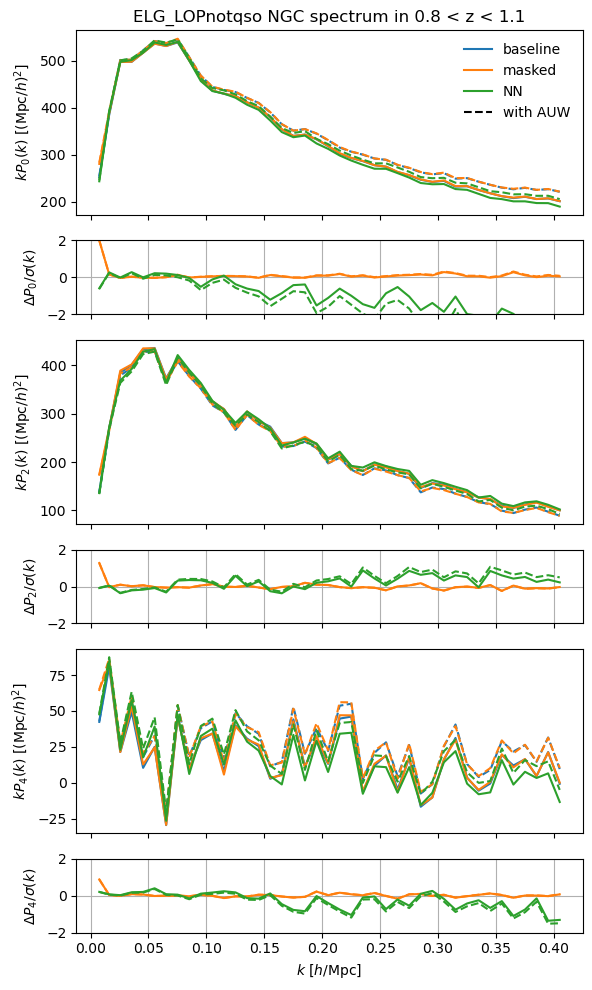

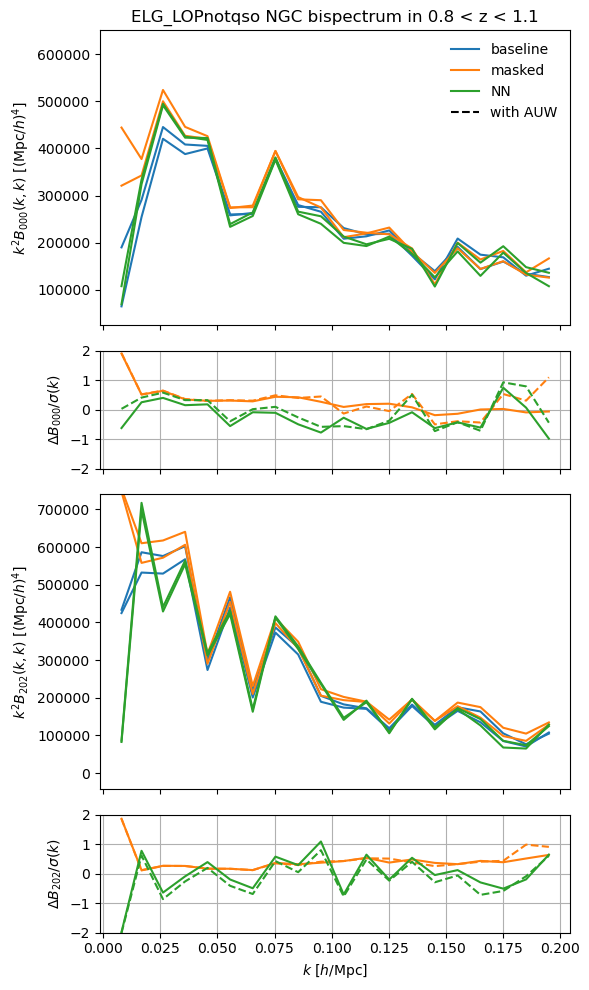

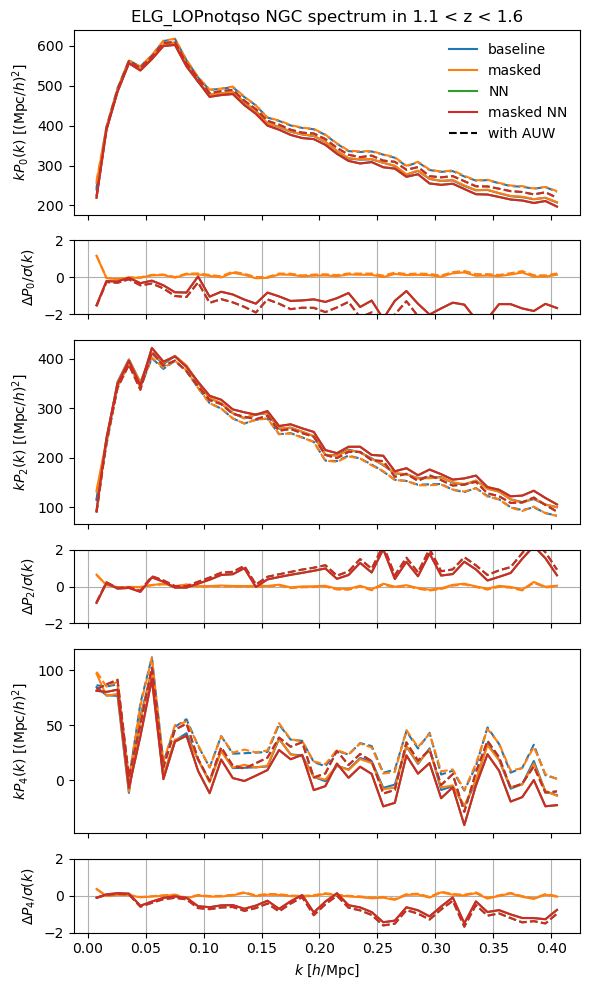

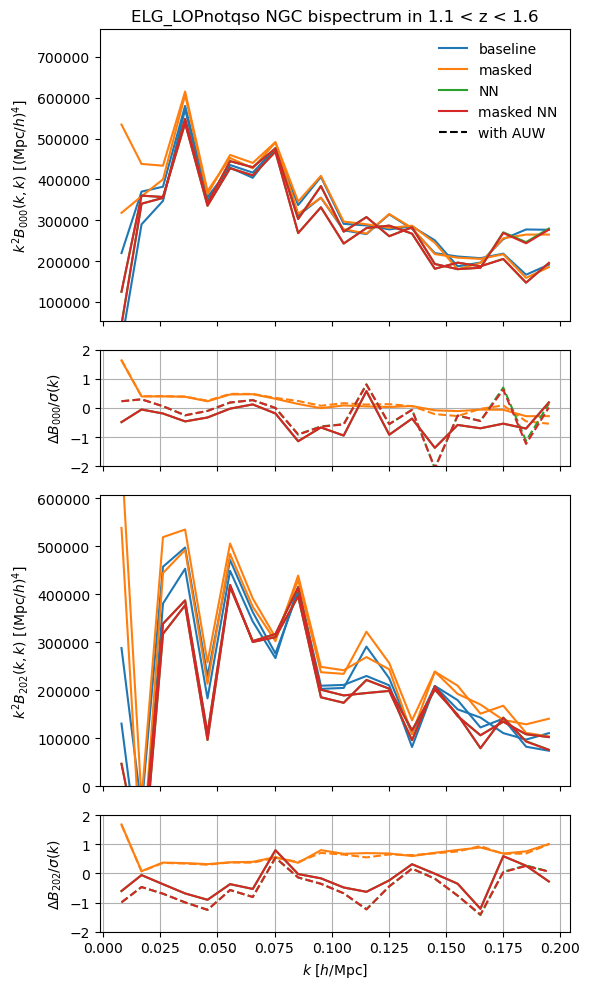

In [8]:
for tracer in ['ELG_LOPnotqso']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum', 'mesh3_spectrum']:
            stats_dir = tools.base_stats_dir
            region = 'NGC'
            version = 'holi-v3-altmtl'
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project='full_shape/base', version=version, tracer=tracer,
                                      zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]

            mocks = [types.read(fn) for fn in fns if fn.exists()]
            cov = types.cov(mocks)
            cov = cov.at.observable.select(k=slice(0, None, 10 if 'mesh2' in kind else 2))
            mean = cov.observable

            project = 'full_shape/fiber_assignment_systematics'
            data, data_auw = {}, {}
            for label, version in {'baseline': 'data-dr2-v2',
                                   'masked': 'data-dr2-test-maskedfracz',
                                   'NN': 'data-dr2-test',
                                   'masked NN': 'data-dr2-test-maskedfraczpNN'}.items():
                fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                          zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal')
                if not fn.exists(): continue
                tmp = types.read(fn).match(mean)
                fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, project=project, version=version, tracer=tracer,
                                          zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', auw=True)
                if not fn.exists(): continue
                tmp_auw = types.read(fn).match(mean)
                data[label], data_auw[label] = tmp, tmp_auw

            colors = [f'C{i:d}' for i in range(10)]
            if 'mesh2' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(mean.ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    for color, label in zip(colors, data):
                        pole = data[label].get(ell)
                        ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                        pole = data_auw[label].get(ell)
                        ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-2., 2.)
                    std = cov.at.observable.get(ell).std() # / nmocks**0.5
                    for color, label in zip(colors, data):
                        if label != 'baseline':
                            pole = data['baseline'].get(ell)
                            pole_nn = data[label].get(ell)
                            ax.plot(pole.coords('k'), (pole_nn.value() - pole.value()) / std, color=color, linestyle='-')
                            pole = data_auw['baseline'].get(ell)
                            pole_nn = data_auw[label].get(ell)
                            ax.plot(pole.coords('k'), (pole_nn.value() - pole.value()) / std, color=color, linestyle='--')
                ax = lax[0]
                for color, label in zip(colors, data):
                    ax.plot([], [], color=color, linestyle='-', label=label)
                ax.plot([], [], color='k', linestyle='--', label='with AUW')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            elif 'mesh3' in kind:
                ells = mean.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} {region} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
                    ymin, ymax = [], []
                    for color, label in zip(colors, data):
                        pole = data[label].get(ell)
                        ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='-')
                        tmp = k**2 * pole.value()
                        ymin.append(tmp[k > 0.02].min())
                        ymax.append(tmp[k > 0.02].max())
                        pole = data_auw[label].get(ell)
                        ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='-')
                    ymin, ymax = np.min(ymin), np.max(ymax)
                    ax.set_ylim(ymin - 0.2 * (ymax - ymin), ymax + 0.2 * (ymax + ymin))
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-2., 2.)
                    #ax.set_ylim(-5e4, 5e4)
                    std = cov.at.observable.get(ell).std() # / nmocks**0.5
                    for color, label in zip(colors, data):
                        if label != 'baseline':
                            pole = data['baseline'].get(ell)
                            pole_nn = data[label].get(ell)
                            ax.plot(k:=pole.coords('k')[..., 0], (pole_nn.value() - pole.value()) / std, color=color, linestyle='-')
                            pole = data_auw['baseline'].get(ell)
                            pole_nn = data_auw[label].get(ell)
                            ax.plot(k:=pole.coords('k')[..., 0], (pole_nn.value() - pole.value()) / std, color=color, linestyle='--')
                ax = lax[0]
                for color, label in zip(colors, data):
                    ax.plot([], [], color=color, linestyle='-', label=label)
                ax.plot([], [], color='k', linestyle='--', label='with AUW')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)

            basename = f'validation_nn_auw_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
            plt.tight_layout()
            fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
            plt.show()